In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 150)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)

DATA_DIR  = r"C:\Users\kavit\OneDrive\Desktop\Apollo_Hospitals_Project\data"
FACT_PATH = os.path.join(DATA_DIR, "apollo_appointments_fact.csv")
DIM_PATH  = os.path.join(DATA_DIR, "apollo_doctors_dim.csv")

print(os.path.exists(FACT_PATH), os.path.exists(DIM_PATH))


True True


In [2]:
fact = pd.read_csv(FACT_PATH, keep_default_na=False, na_values=[""])
doctors = pd.read_csv(DIM_PATH, keep_default_na=False, na_values=[""])

print("Fact table shape :", fact.shape)
print("Doctors table shape :",doctors.shape)

Fact table shape : (75000, 52)
Doctors table shape : (320, 15)


In [3]:
fact.info()

<class 'pandas.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 52 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   appointment_id              75000 non-null  str    
 1   patient_id                  75000 non-null  str    
 2   doctor_id                   75000 non-null  str    
 3   appointment_date            75000 non-null  str    
 4   appointment_day             75000 non-null  str    
 5   appointment_day_of_week     75000 non-null  int64  
 6   appointment_month           75000 non-null  int64  
 7   appointment_quarter         75000 non-null  str    
 8   appointment_year            75000 non-null  int64  
 9   appointment_hour            75000 non-null  int64  
 10  appointment_minute          75000 non-null  int64  
 11  time_slot                   75000 non-null  str    
 12  time_of_day                 75000 non-null  str    
 13  booking_date                75000 non-null

In [4]:
doctors.info()

<class 'pandas.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   doctor_id              320 non-null    str    
 1   doctor_name            320 non-null    str    
 2   specialty              320 non-null    str    
 3   qualification          320 non-null    str    
 4   experience_years       320 non-null    int64  
 5   city                   320 non-null    str    
 6   state                  320 non-null    str    
 7   hospital_name          320 non-null    str    
 8   consultation_fee       320 non-null    int64  
 9   rating                 320 non-null    float64
 10  total_reviews          320 non-null    int64  
 11  available_days         320 non-null    str    
 12  avg_slot_duration_min  320 non-null    int64  
 13  accepts_insurance      320 non-null    str    
 14  teleconsult_enabled    320 non-null    str    
dtypes: float64(1), in

In [5]:
fact.isna().sum().loc[lambda s: s>0]

wait_time_minutes             19725
consultation_duration_min     19725
patient_satisfaction_score    19725
doctor_utilization_pct        19725
dtype: int64

In [6]:
fact["patient_chronic_condition"].value_counts()

patient_chronic_condition
None              28038
Hypothyroidism     9452
Heart Disease      9445
Hypertension       9394
Asthma             9388
Diabetes           9283
Name: count, dtype: int64

In [7]:
print("Duplicate appointment_id:", fact["appointment_id"].duplicated().sum())
print("Full duplicate rows     :", fact.duplicated().sum())
print("Duplicate doctor_id     :", doctors["doctor_id"].duplicated().sum())

Duplicate appointment_id: 0
Full duplicate rows     : 0
Duplicate doctor_id     : 0


In [8]:
fact["appointment_status"].value_counts()

appointment_status
Completed    55275
No-Show      11584
Cancelled     5793
Scheduled     2348
Name: count, dtype: int64

In [9]:
quality_cols = ["wait_time_minutes", "consultation_duration_min",
                "patient_satisfaction_score", "doctor_utilization_pct"]
fact.groupby("appointment_status")[quality_cols].apply(lambda x: x.isna().sum())

,wait_time_minutes,consultation_duration_min,patient_satisfaction_score,doctor_utilization_pct
appointment_status,,,,
Cancelled,5793,5793,5793,5793
Completed,0,0,0,0
No-Show,11584,11584,11584,11584
Scheduled,2348,2348,2348,2348


In [10]:
df = fact.copy()

df["appointment_date"] = pd.to_datetime(df["appointment_date"])
df["booking_date"]     = pd.to_datetime(df["booking_date"])

print("Unparseable appointment dates:", df["appointment_date"].isna().sum())
print("Unparseable booking dates:", df["booking_date"].isna().sum())
print("Data range:", df["appointment_date"].min().date(),"to",df["appointment_date"].max().date())
print("Bookings made AFTER the appointment):",(df["booking_date"]>df["appointment_date"]).sum())

Unparseable appointment dates: 0
Unparseable booking dates: 0
Data range: 2022-01-01 to 2024-12-31
Bookings made AFTER the appointment): 0


In [11]:
resolved = df[df["appointment_status"] != "Scheduled"].copy()
completed = df[df["appointment_status"]== "completed"].copy()

print("df        :",df.shape[0],"rows")
print("resolved  :",resolved.shape[0],"rows (75,000 minus Scheduled)")
print("copleted  :",completed.shape[0],"rows (Completed only)")

df        : 75000 rows
resolved  : 72652 rows (75,000 minus Scheduled)
copleted  : 0 rows (Completed only)


In [12]:
dec_2024 = df[(df["appointment_year"]==2024) & (df["appointment_month"]==12)]
dec_2024["appointment_status"].value_counts()

appointment_status
Scheduled    2348
Name: count, dtype: int64

In [13]:
df["year_month"]   = df["appointment_date"].dt.to_period("M").astype(str)
df["year_quarter"] = df["appointment_year"].astype(str) + "-" + df["appointment_quarter"]

df["is_weekend"] = df["appointment_day_of_week"] >= 5

lead_bins   = [-1, 0, 1, 3, 7, 14, 30]
lead_labels = ["0 (Same day)", "1 day", "2-3 days", "4-7 days", "8-14 days", "15-30 days"]
df["lead_time_group"] = pd.cut(df["booking_lead_days"], bins=lead_bins, labels=lead_labels)

df["prior_no_show_group"] = pd.cut(df["patient_prior_no_shows"], bins=[-1, 0, 1, 2, 100],
                                    labels=["0", "1", "2", "3+"])

df["chronic_flag"] = np.where(df["patient_chronic_condition"] == "None", "No", "Yes")

df["duration_band"] = pd.cut(df["consultation_duration_min"], bins=[0, 10, 20, 30, 50],
                              labels=["≤10 min", "11-20 min", "21-30 min", "31+ min"])

resolved = resolved.merge(df[["appointment_id", "year_month", "year_quarter", "is_weekend",
                               "lead_time_group", "prior_no_show_group", "chronic_flag"]],
                           on="appointment_id", how="left")
completed = completed.merge(df[["appointment_id", "duration_band"]], on="appointment_id", how="left")

print("Derived columns added.")
df[["year_month", "year_quarter", "is_weekend", "lead_time_group",
    "prior_no_show_group", "chronic_flag"]].head(3)

Derived columns added.


,year_month,year_quarter,is_weekend,lead_time_group,prior_no_show_group,chronic_flag
0,2023-11,2023-Q4,False,1 day,0,No
1,2023-03,2023-Q1,False,8-14 days,0,No
2,2022-02,2022-Q1,False,0 (Same day),0,Yes


In [14]:
doc_cols = ["doctor_id", "doctor_name", "qualification", "experience_years",
            "rating", "total_reviews", "avg_slot_duration_min",
            "accepts_insurance", "teleconsult_enabled", "consultation_fee"]

doc_small = doctors[doc_cols].rename(columns={"consultation_fee": "doctor_std_fee"})

df = df.merge(doc_small, on="doctor_id", how="left", validate="m:1", indicator=True)

print("Rows after join       :", df.shape[0], "(should still be 75,000)")
print("Merge match summary   :")
print(df["_merge"].value_counts())
print("Nulls in doctor columns:", df[doc_cols[1:]].isna().sum().sum())
print("appointment_id still unique:", df["appointment_id"].is_unique)

df = df.drop(columns="_merge")

Rows after join       : 75000 (should still be 75,000)
Merge match summary   :
_merge
both          75000
left_only         0
right_only        0
Name: count, dtype: int64
Nulls in doctor columns: 0
appointment_id still unique: True


In [15]:
completed = completed.merge(df[["appointment_id", "experience_years", "doctor_std_fee"]],
                             on="appointment_id", how="left")
print("completed shape:", completed.shape)

completed shape: (0, 55)


In [16]:
def no_show_rate_by(column, data=resolved):
    """Returns no-show rate (%) and row count per category of `column`, sorted descending by rate."""
    out = data.groupby(column, observed=True).agg(
        no_show_rate=("no_show_flag", "mean"),
        appointments=("no_show_flag", "size")
    )
    out["no_show_rate"] = (out["no_show_rate"] * 100).round(1)
    return out.sort_values("no_show_rate", ascending=False)

In [17]:
#Business Overview

In [18]:
#Volume trend

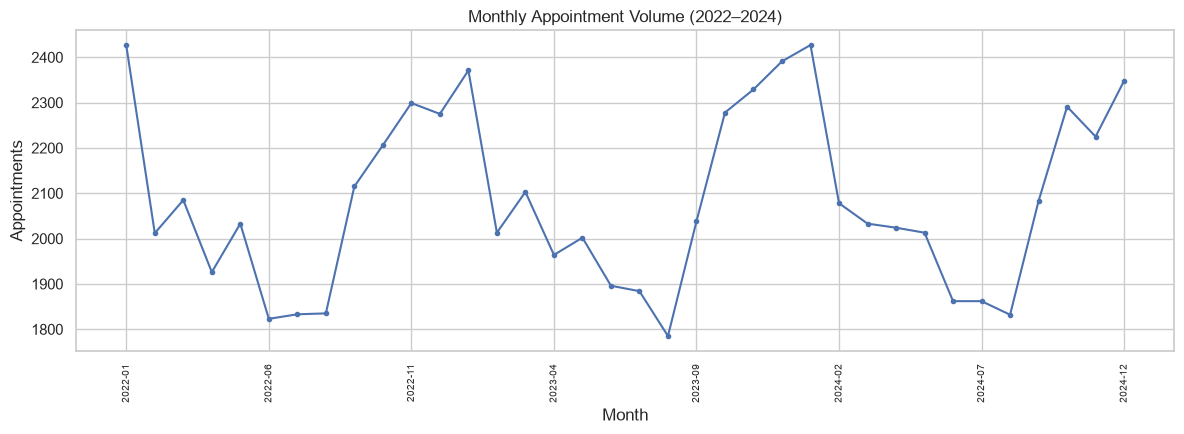

count      36.000000
mean     2083.333333
std       195.116376
min      1785.000000
25%      1918.500000
50%      2035.500000
75%      2275.750000
max      2427.000000
dtype: float64

In [19]:
monthly_volume = df.groupby("year_month").size()

plt.figure(figsize=(12, 4.5))
monthly_volume.plot(kind="line", marker="o", markersize=3)
plt.title("Monthly Appointment Volume (2022–2024)")
plt.xlabel("Month"); plt.ylabel("Appointments")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

monthly_volume.describe()

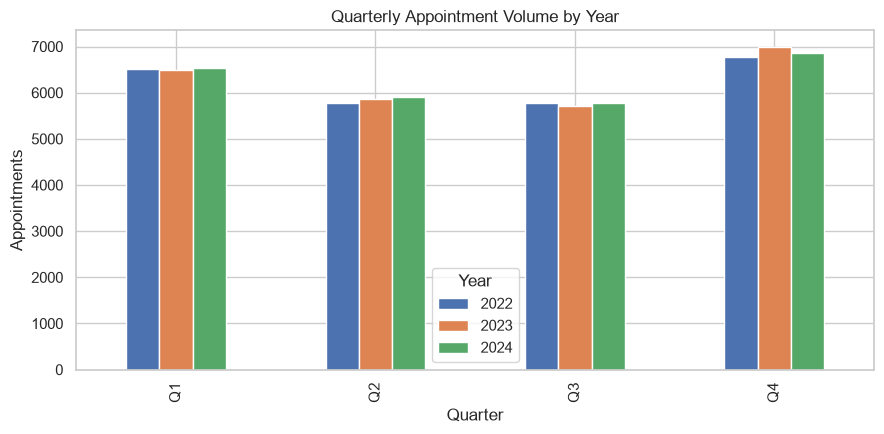

appointment_quarter,Q1,Q2,Q3,Q4
appointment_year,,,,
2022,6523,5782,5783,6780
2023,6487,5862,5707,6998
2024,6538,5899,5777,6864


In [20]:
quarterly_volume = df.groupby(["appointment_year", "appointment_quarter"]).size().unstack()

quarterly_volume.T.plot(kind="bar", figsize=(9, 4.5))
plt.title("Quarterly Appointment Volume by Year")
plt.xlabel("Quarter"); plt.ylabel("Appointments")
plt.legend(title="Year")
plt.tight_layout()
plt.show()

quarterly_volume

In [21]:
#Outcome split


In [22]:
status_split = df["appointment_status"].value_counts()
status_pct   = (df["appointment_status"].value_counts(normalize=True) * 100).round(1)

pd.DataFrame({"count": status_split, "pct": status_pct})

,count,pct
appointment_status,,
Completed,55275,73.7
No-Show,11584,15.4
Cancelled,5793,7.7
Scheduled,2348,3.1


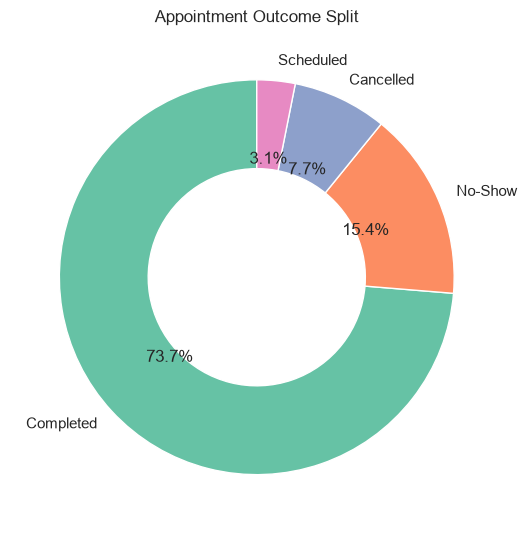

In [23]:
plt.figure(figsize=(5.5, 5.5))
colors = sns.color_palette("Set2", len(status_split))
plt.pie(status_split, labels=status_split.index, autopct="%1.1f%%", startangle=90,
        colors=colors, wedgeprops=dict(width=0.45))
plt.title("Appointment Outcome Split")
plt.tight_layout()
plt.show()

In [24]:
#Channel mix

In [25]:
channel_volume = df["booking_channel"].value_counts()
channel_pct    = (df["booking_channel"].value_counts(normalize=True) * 100).round(1)

pd.DataFrame({"count": channel_volume, "pct": channel_pct})

,count,pct
booking_channel,,
Apollo App,34042,45.4
Website,18545,24.7
Call Centre,11201,14.9
Walk-In,7501,10.0
Partner App,3711,4.9


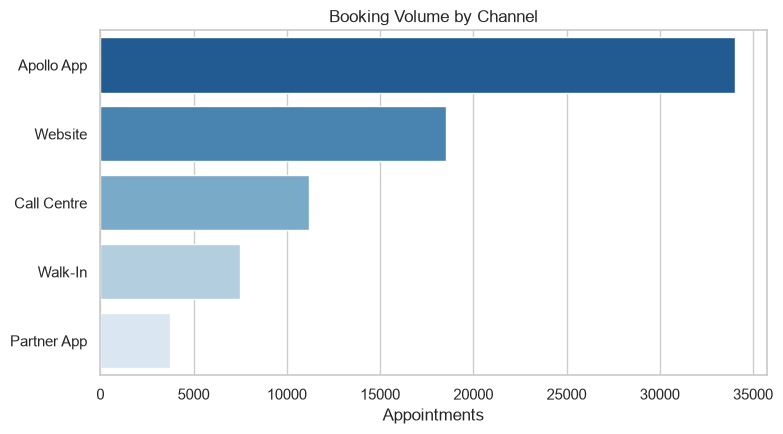

In [26]:
plt.figure(figsize=(8, 4.5))
sns.barplot(x=channel_volume.values, y=channel_volume.index, hue=channel_volume.index,
            palette="Blues_r", legend=False)
plt.title("Booking Volume by Channel")
plt.xlabel("Appointments"); plt.ylabel("")
plt.tight_layout()
plt.show()

In [27]:
#No Show Analysis

In [28]:
#No show rate by speciality and city

In [29]:
specialty_ns = no_show_rate_by("specialty")
specialty_ns

,no_show_rate,appointments
specialty,,
Psychiatry,24.5,2900
Dermatology,21.3,7566
ENT,19.0,5211
Endocrinology,17.5,2024
Ophthalmology,16.2,3103
General Physician,15.5,19654
Pulmonology,15.5,2549
Gastroenterology,14.9,2527
Orthopaedics,14.9,5419


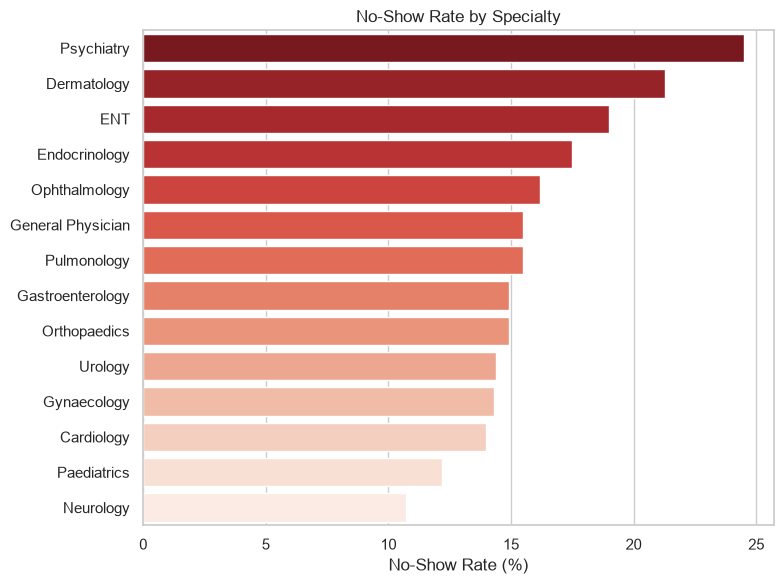

In [30]:
plt.figure(figsize=(8, 6))
sns.barplot(x="no_show_rate", y=specialty_ns.index, data=specialty_ns,
            hue=specialty_ns.index, palette="Reds_r", legend=False)
plt.title("No-Show Rate by Specialty")
plt.xlabel("No-Show Rate (%)"); plt.ylabel("")
plt.tight_layout()
plt.show()

In [31]:
city_ns = no_show_rate_by("city")
city_ns

,no_show_rate,appointments
city,,
Lucknow,17.2,3001
Mumbai,17.0,9734
Delhi,16.9,10404
Bhopal,16.8,2001
Kolkata,16.4,5701
Kochi,16.3,2690
Ahmedabad,16.2,3468
Jaipur,16.2,2653
Hyderabad,16.0,7229


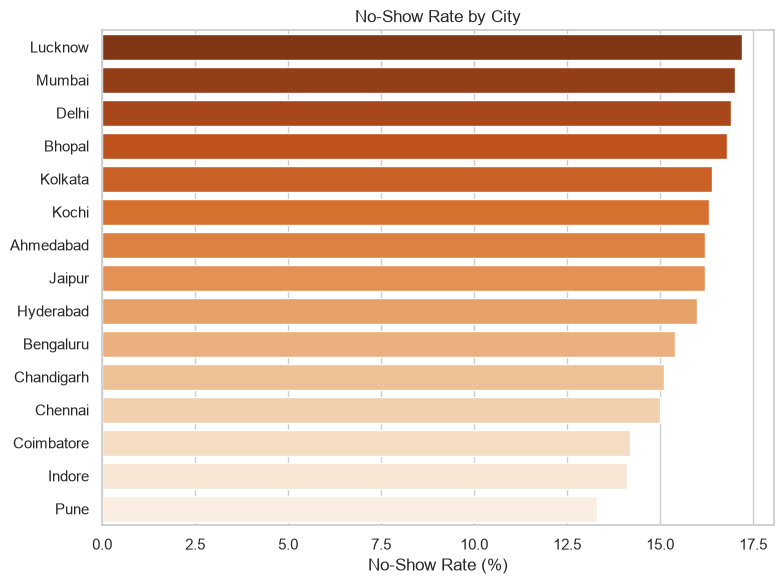

In [32]:
plt.figure(figsize=(8, 6))
sns.barplot(x="no_show_rate", y=city_ns.index, data=city_ns,
            hue=city_ns.index, palette="Oranges_r", legend=False)
plt.title("No-Show Rate by City")
plt.xlabel("No-Show Rate (%)"); plt.ylabel("")
plt.tight_layout()
plt.show()

In [33]:
#Lead time effect

In [34]:
lead_ns = no_show_rate_by("lead_time_group").reindex(
    ["0(same day)","1 day","2-3 days","4-7 days","8-14 days","15-30 days"]
)
lead_ns

,no_show_rate,appointments
lead_time_group,,
0(same day),NaN,NaN
1 day,13.2,10453.0
2-3 days,15.1,15022.0
4-7 days,16.5,15897.0
8-14 days,18.8,8758.0
15-30 days,20.0,2342.0


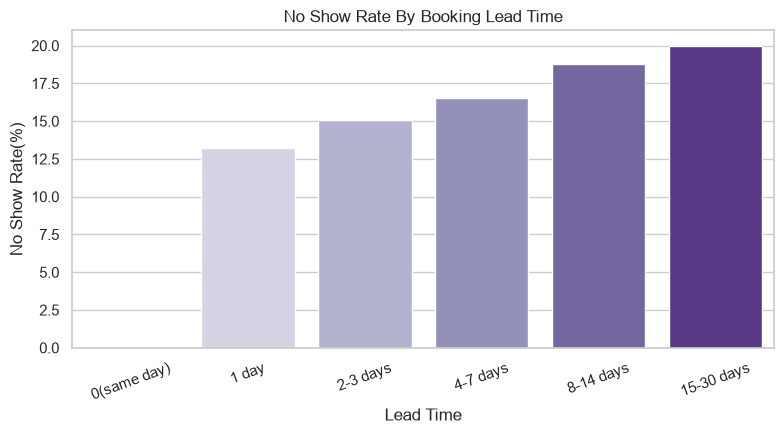

In [35]:
plt.figure(figsize=(8,4.5))
sns.barplot(x=lead_ns.index, y="no_show_rate", data=lead_ns,
           hue=lead_ns.index, palette="Purples", legend=False)

plt.title("No Show Rate By Booking Lead Time")
plt.xlabel("Lead Time"); plt.ylabel("No Show Rate(%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [36]:
#Evening/weekend effect

In [37]:
time_of_day_ns = no_show_rate_by("time_of_day")
time_of_day_ns

,no_show_rate,appointments
time_of_day,,
Evening,18.4,14553
Afternoon,17.8,23231
Morning,13.7,34868


In [38]:
weekend_ns = no_show_rate_by("is_weekend")
weekend_ns.index = weekend_ns.index.map({True: "Weekend", False: "Weekday"})
weekend_ns

,no_show_rate,appointments
is_weekend,,
Weekend,18.7,20921
Weekday,14.8,51731


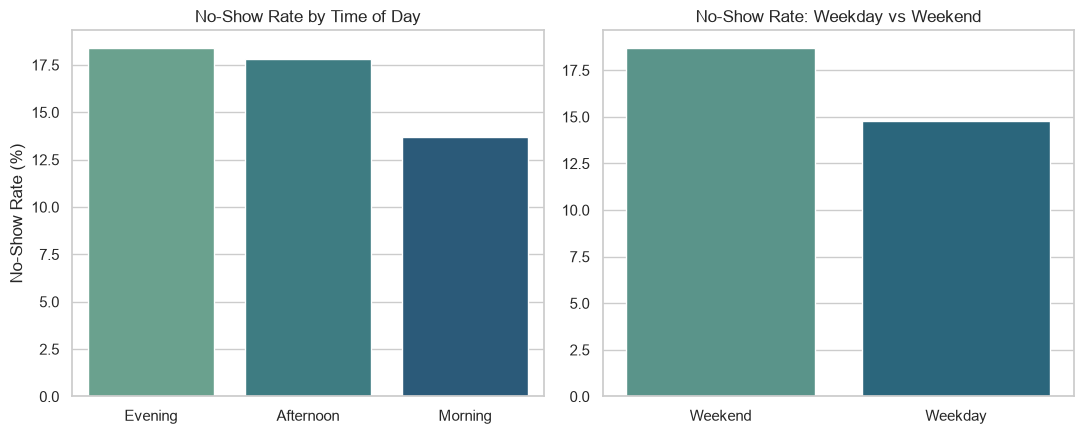

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.barplot(x=time_of_day_ns.index, y="no_show_rate", data=time_of_day_ns,
            hue=time_of_day_ns.index, palette="crest", legend=False, ax=axes[0])
axes[0].set_title("No-Show Rate by Time of Day")
axes[0].set_xlabel(""); axes[0].set_ylabel("No-Show Rate (%)")

sns.barplot(x=weekend_ns.index, y="no_show_rate", data=weekend_ns,
            hue=weekend_ns.index, palette="crest", legend=False, ax=axes[1])
axes[1].set_title("No-Show Rate: Weekday vs Weekend")
axes[1].set_xlabel(""); axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [40]:
#Appointment type / channel risk

In [41]:
type_ns = no_show_rate_by("appointment_type")
type_ns

,no_show_rate,appointments
appointment_type,,
Home Visit,26.2,9742
Video Consult,21.1,15349
In-Clinic,12.2,47561


In [42]:
channel_ns = no_show_rate_by("booking_channel")
channel_ns

,no_show_rate,appointments
booking_channel,,
Walk-In,20.9,7281
Partner App,18.1,3594
Website,17.2,17964
Call Centre,15.2,10855
Apollo App,14.2,32958


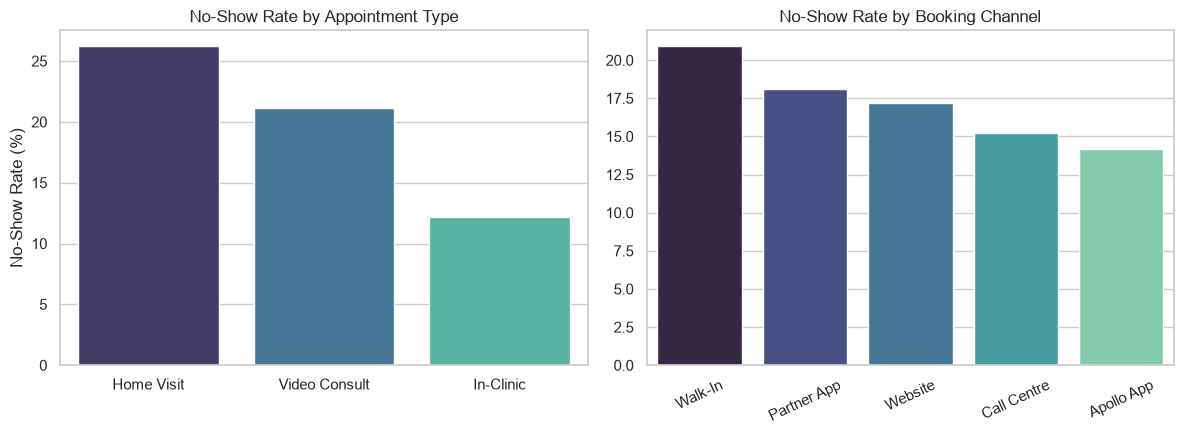

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.barplot(x=type_ns.index, y="no_show_rate", data=type_ns,
            hue=type_ns.index, palette="mako", legend=False, ax=axes[0])
axes[0].set_title("No-Show Rate by Appointment Type")
axes[0].set_xlabel(""); axes[0].set_ylabel("No-Show Rate (%)")

sns.barplot(x=channel_ns.index, y="no_show_rate", data=channel_ns,
            hue=channel_ns.index, palette="mako", legend=False, ax=axes[1])
axes[1].set_title("No-Show Rate by Booking Channel")
axes[1].set_xlabel(""); axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

In [44]:
#Reminder & Engagement

In [45]:
#Reminder effectiveness

In [46]:
reminder_order = ["No Reminder", "SMS Only", "SMS + WhatsApp", "SMS + WhatsApp + Call"]
reminder_ns = no_show_rate_by("reminder_type").reindex(reminder_order)

baseline = reminder_ns.loc["No Reminder", "no_show_rate"]
reminder_ns["pp_change_vs_no_reminder"] = (reminder_ns["no_show_rate"] - baseline).round(1)
reminder_ns

,no_show_rate,appointments,pp_change_vs_no_reminder
reminder_type,,,
No Reminder,30.2,10977,0.0
SMS Only,16.3,14527,-13.9
SMS + WhatsApp,13.5,25273,-16.7
SMS + WhatsApp + Call,11.4,21875,-18.8


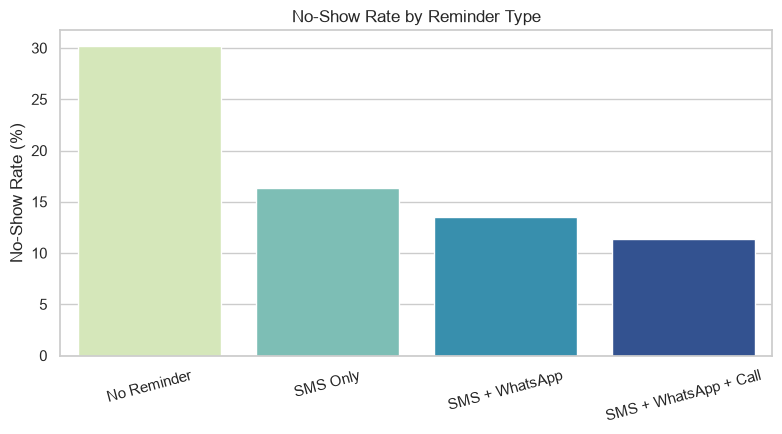

In [47]:
plt.figure(figsize=(8, 4.5))
sns.barplot(x=reminder_ns.index, y="no_show_rate", data=reminder_ns,
            hue=reminder_ns.index, palette="YlGnBu", legend=False)
plt.title("No-Show Rate by Reminder Type")
plt.xlabel(""); plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [77]:
#Prior no show history

In [78]:
prior_ns = no_show_rate_by("prior_no_show_group").reindex(["0", "1", "2", "3+"])
prior_ns

,no_show_rate,appointments
prior_no_show_group,,
0,15.2,63014
1,20.3,8502
2,26.7,983
3+,32.7,153


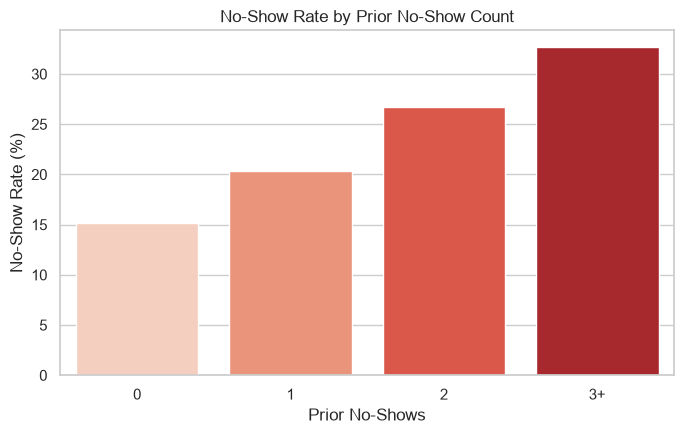

In [79]:
plt.figure(figsize=(7, 4.5))
sns.barplot(x=prior_ns.index, y="no_show_rate", data=prior_ns,
            hue=prior_ns.index, palette="Reds", legend=False)
plt.title("No-Show Rate by Prior No-Show Count")
plt.xlabel("Prior No-Shows"); plt.ylabel("No-Show Rate (%)")
plt.tight_layout()
plt.show()

In [80]:
#Members or Repeat patients

In [81]:
member_ns = no_show_rate_by("apollo_member")
member_ns

,no_show_rate,appointments
apollo_member,,
No,16.9,56428
Yes,12.7,16224


In [82]:
repeat_ns = no_show_rate_by("repeat_visit")
repeat_ns

,no_show_rate,appointments
repeat_visit,,
No,66.8,9182
Yes,8.6,63470


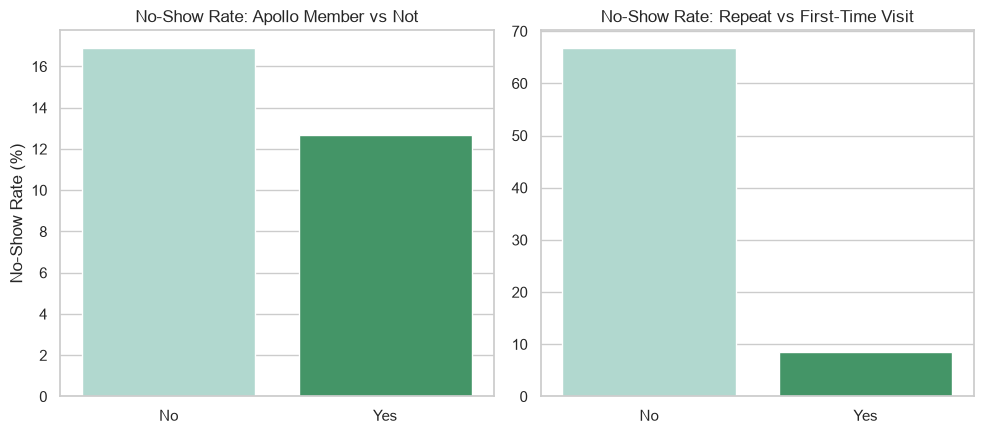

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

sns.barplot(x=member_ns.index, y="no_show_rate", data=member_ns,
            hue=member_ns.index, palette="BuGn", legend=False, ax=axes[0])
axes[0].set_title("No-Show Rate: Apollo Member vs Not")
axes[0].set_xlabel(""); axes[0].set_ylabel("No-Show Rate (%)")

sns.barplot(x=repeat_ns.index, y="no_show_rate", data=repeat_ns,
            hue=repeat_ns.index, palette="BuGn", legend=False, ax=axes[1])
axes[1].set_title("No-Show Rate: Repeat vs First-Time Visit")
axes[1].set_xlabel(""); axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [84]:
#Patient & Demographic Segmentation

In [85]:
#Age / Gender / Chronic condition

In [86]:
age_order = sorted(resolved["age_group"].unique(),
                    key=lambda x: resolved.loc[resolved["age_group"] == x, "patient_age"].mean())
age_ns = no_show_rate_by("age_group").reindex(age_order)
age_ns

,no_show_rate,appointments
age_group,,
Child (0-12),13.5,11745
Teen (13-18),14.7,6379
Young Adult (19-30),17.9,10017
Adult (31-45),18.0,15133
Middle-aged (46-60),16.8,14862
Senior (60+),14.0,14516


In [87]:
gender_ns = no_show_rate_by("patient_gender")
gender_ns

,no_show_rate,appointments
patient_gender,,
Female,16.0,37589
Male,15.8,35063


In [88]:
chronic_ns = no_show_rate_by("chronic_flag")
chronic_ns

,no_show_rate,appointments
chronic_flag,,
Yes,16.0,45508
No,15.9,27144


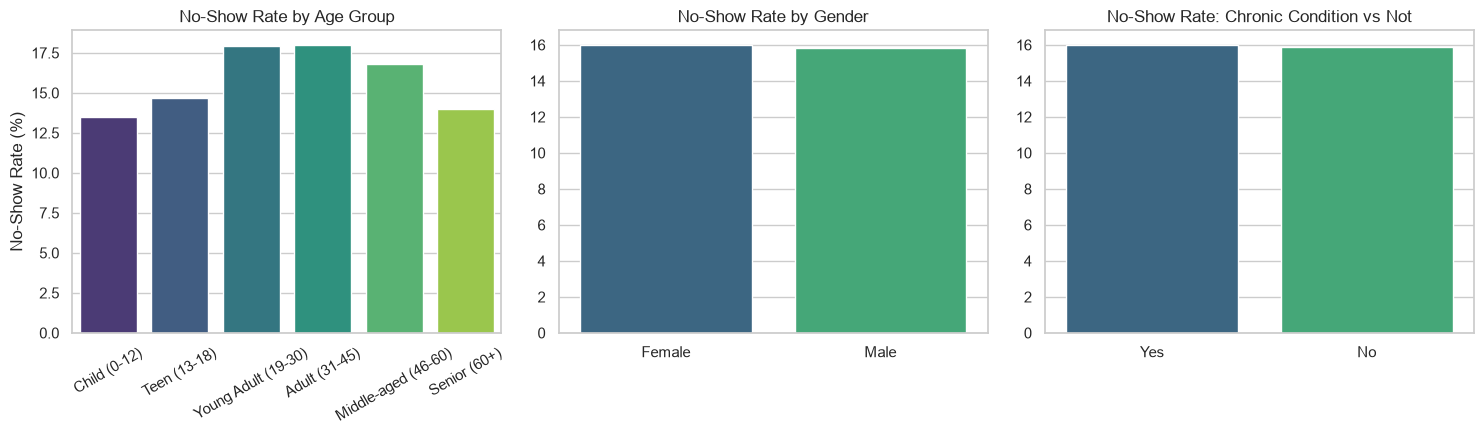

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.barplot(x=age_ns.index, y="no_show_rate", data=age_ns,
            hue=age_ns.index, palette="viridis", legend=False, ax=axes[0])
axes[0].set_title("No-Show Rate by Age Group")
axes[0].set_xlabel(""); axes[0].set_ylabel("No-Show Rate (%)")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(x=gender_ns.index, y="no_show_rate", data=gender_ns,
            hue=gender_ns.index, palette="viridis", legend=False, ax=axes[1])
axes[1].set_title("No-Show Rate by Gender")
axes[1].set_xlabel(""); axes[1].set_ylabel("")

sns.barplot(x=chronic_ns.index, y="no_show_rate", data=chronic_ns,
            hue=chronic_ns.index, palette="viridis", legend=False, ax=axes[2])
axes[2].set_title("No-Show Rate: Chronic Condition vs Not")
axes[2].set_xlabel(""); axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

In [90]:
#Visit Reason

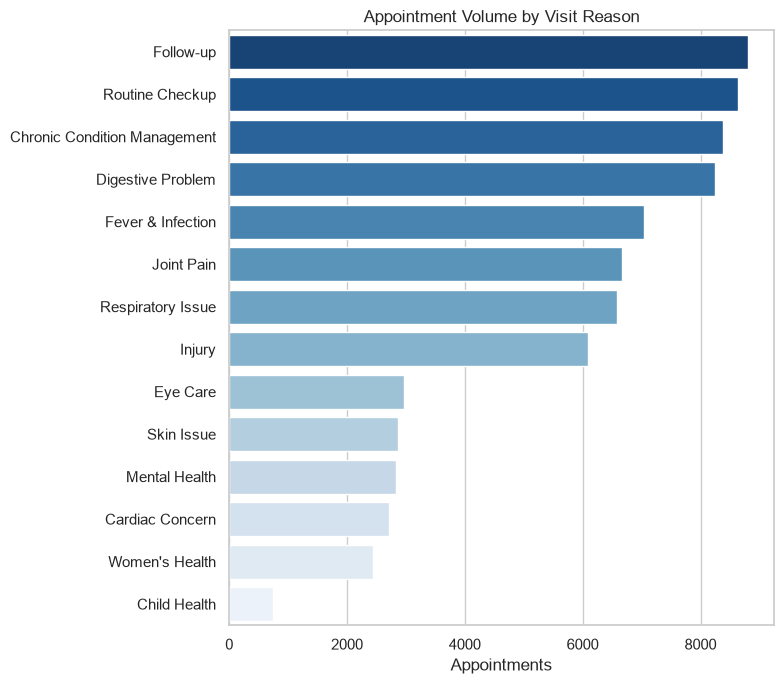

In [91]:
reason_volume = df["visit_reason"].value_counts()

plt.figure(figsize=(8, 7))
sns.barplot(x=reason_volume.values, y=reason_volume.index, hue=reason_volume.index,
            palette="Blues_r", legend=False)
plt.title("Appointment Volume by Visit Reason")
plt.xlabel("Appointments"); plt.ylabel("")
plt.tight_layout()
plt.show()

In [92]:
reason_ns = no_show_rate_by("visit_reason")
reason_ns

,no_show_rate,appointments
visit_reason,,
Skin Issue,16.8,2782
Joint Pain,16.7,6469
Cardiac Concern,16.3,2639
Mental Health,16.3,2733
Digestive Problem,16.2,7984
Fever & Infection,16.1,6808
Injury,16.1,5884
Women's Health,16.0,2362
Respiratory Issue,16.0,6383


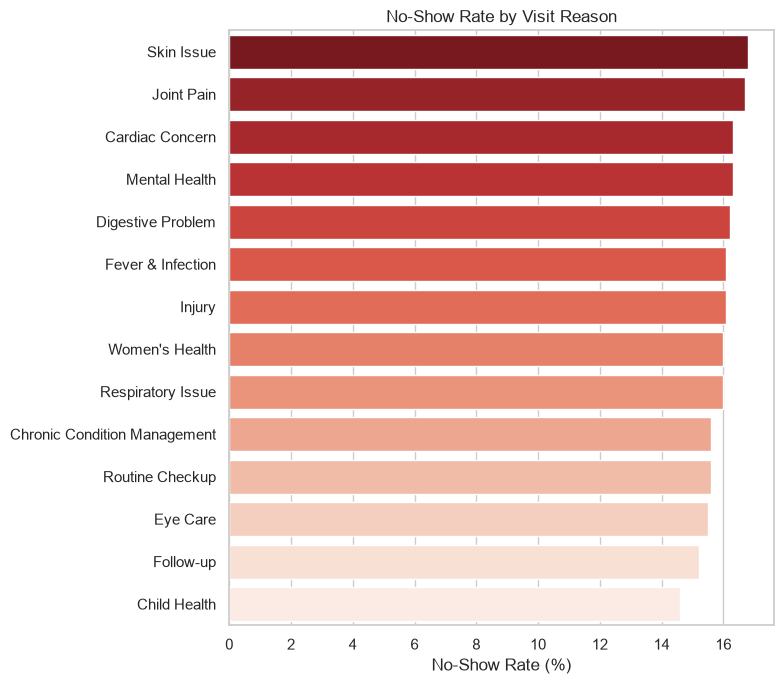

In [93]:
plt.figure(figsize=(8, 7))
sns.barplot(x="no_show_rate", y=reason_ns.index, data=reason_ns,
            hue=reason_ns.index, palette="Reds_r", legend=False)
plt.title("No-Show Rate by Visit Reason")
plt.xlabel("No-Show Rate (%)"); plt.ylabel("")
plt.tight_layout()
plt.show()

In [94]:
#Age distribution : Paediatrics , Gynaecology , Psychiatry

In [95]:
three_specialties = ["Paediatrics", "Gynaecology", "Psychiatry"]
age_subset = df[df["specialty"].isin(three_specialties)]

age_subset.groupby("specialty")["patient_age"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
specialty,,,,,,,,
Gynaecology,4113.0,41.7,21.7,1.0,25.0,42.0,59.0,85.0
Paediatrics,6382.0,9.3,5.0,1.0,5.0,9.0,14.0,18.0
Psychiatry,2989.0,42.0,21.7,1.0,25.0,42.0,59.0,85.0


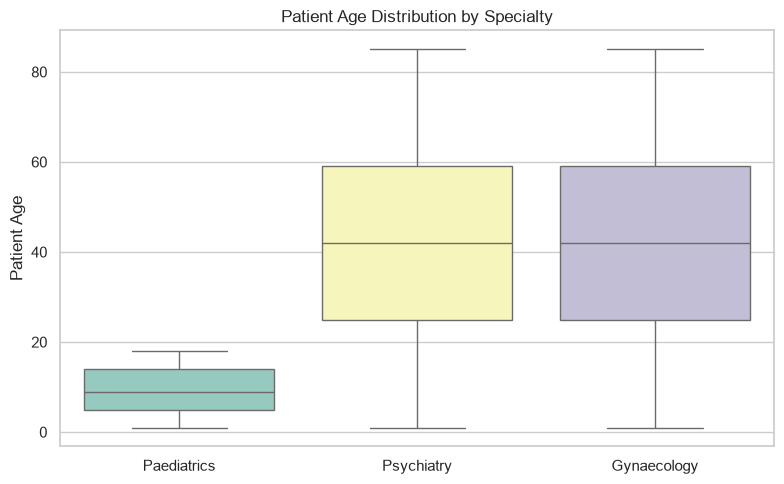

In [96]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="specialty", y="patient_age", data=age_subset,
            hue="specialty", palette="Set3", legend=False)
plt.title("Patient Age Distribution by Specialty")
plt.xlabel(""); plt.ylabel("Patient Age")
plt.tight_layout()
plt.show()

In [97]:
#Financial Performance

In [111]:
#Revenue lost to no shows

In [115]:
no_show_rows = resolved[resolved["appointment_status"] == "No-Show"]

billed_value_at_risk = no_show_rows["consultation_fee"].sum()
print(f"Billed value at risk (listed fee of all No-Show appointments): Rs {billed_value_at_risk:,.0f}")

Billed value at risk (listed fee of all No-Show appointments): Rs 19,725,460


In [116]:
avg_revenue_by_specialty = completed.groupby("specialty")["revenue_realized"].mean()
no_show_count_by_specialty = no_show_rows.groupby("specialty").size()

modeled_loss_by_specialty = (no_show_count_by_specialty * avg_revenue_by_specialty).dropna().sort_values(ascending=False)
modeled_loss_by_specialty = modeled_loss_by_specialty.round(0)

print(f"Total modeled revenue loss: Rs {modeled_loss_by_specialty.sum():,.0f}")
modeled_loss_by_specialty

Total modeled revenue loss: Rs 15,656,318


specialty
Dermatology          2101531.0
General Physician    1929389.0
Psychiatry           1877358.0
Orthopaedics         1253230.0
Cardiology           1220741.0
ENT                  1190023.0
Neurology            1069387.0
Gynaecology           853268.0
Ophthalmology         737964.0
Paediatrics           717993.0
Gastroenterology      715100.0
Pulmonology           710472.0
Endocrinology         643503.0
Urology               636359.0
dtype: float64

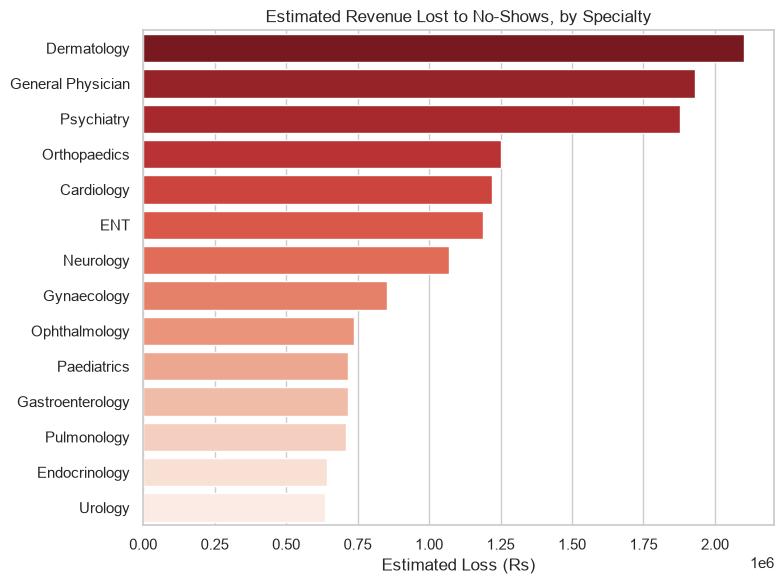

In [117]:
plt.figure(figsize=(8, 6))
sns.barplot(x=modeled_loss_by_specialty.values, y=modeled_loss_by_specialty.index,
            hue=modeled_loss_by_specialty.index, palette="Reds_r", legend=False)
plt.title("Estimated Revenue Lost to No-Shows, by Specialty")
plt.xlabel("Estimated Loss (Rs)"); plt.ylabel("")
plt.tight_layout()
plt.show()

In [118]:
#Revenue by speciality or appointent type

In [119]:
revenue_by_specialty = completed.groupby("specialty")["revenue_realized"].mean().sort_values(ascending=False).round(0)
revenue_by_specialty

specialty
Psychiatry           2640.0
Neurology            2076.0
Urology              1989.0
Cardiology           1941.0
Gastroenterology     1897.0
Endocrinology        1813.0
Pulmonology          1803.0
Orthopaedics         1547.0
Gynaecology          1500.0
Ophthalmology        1467.0
Dermatology          1307.0
ENT                  1204.0
Paediatrics           950.0
General Physician     633.0
Name: revenue_realized, dtype: float64

In [120]:
revenue_by_type = completed.groupby("appointment_type")["revenue_realized"].mean().sort_values(ascending=False).round(0)
revenue_by_type

appointment_type
Home Visit       1960.0
In-Clinic        1300.0
Video Consult    1098.0
Name: revenue_realized, dtype: float64

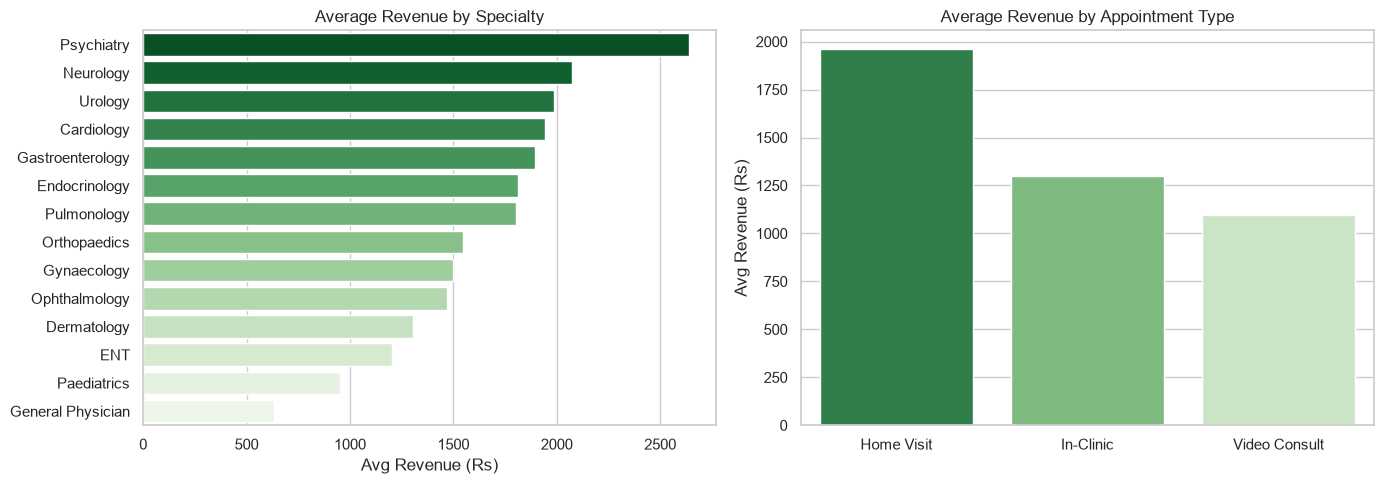

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=revenue_by_specialty.values, y=revenue_by_specialty.index,
            hue=revenue_by_specialty.index, palette="Greens_r", legend=False, ax=axes[0])
axes[0].set_title("Average Revenue by Specialty")
axes[0].set_xlabel("Avg Revenue (Rs)"); axes[0].set_ylabel("")

sns.barplot(x=revenue_by_type.index, y=revenue_by_type.values,
            hue=revenue_by_type.index, palette="Greens_r", legend=False, ax=axes[1])
axes[1].set_title("Average Revenue by Appointment Type")
axes[1].set_xlabel(""); axes[1].set_ylabel("Avg Revenue (Rs)")

plt.tight_layout()
plt.show()

In [122]:
#City revenue & payment mix

In [123]:
revenue_by_city = completed.groupby("city")["revenue_realized"].sum().sort_values(ascending=False).round(0)
revenue_by_city

city
Bengaluru     9990616
Delhi         9958247
Mumbai        8989613
Hyderabad     7503245
Chennai       7188473
Kolkata       6543084
Pune          4734139
Ahmedabad     3956890
Lucknow       3177444
Indore        2223207
Chandigarh    2221091
Jaipur        2199116
Coimbatore    1792804
Kochi         1731448
Bhopal        1684381
Name: revenue_realized, dtype: int64

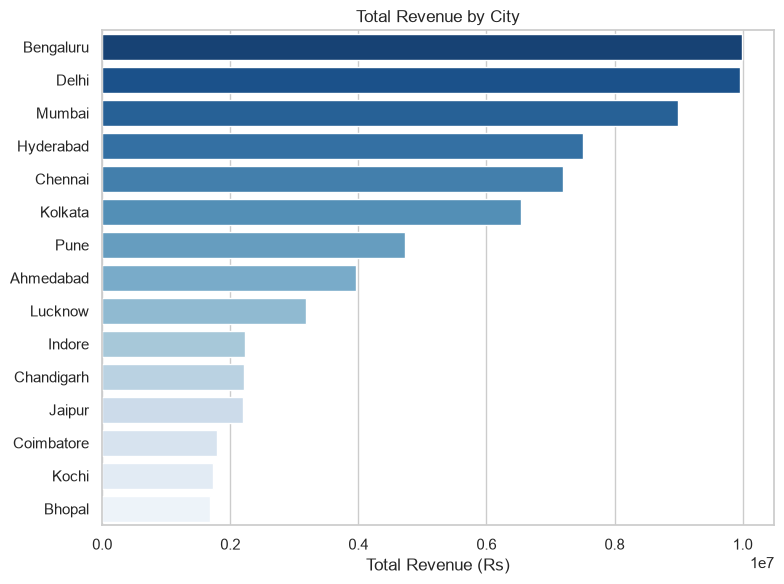

In [124]:
plt.figure(figsize=(8, 6))
sns.barplot(x=revenue_by_city.values, y=revenue_by_city.index,
            hue=revenue_by_city.index, palette="Blues_r", legend=False)
plt.title("Total Revenue by City")
plt.xlabel("Total Revenue (Rs)"); plt.ylabel("")
plt.tight_layout()
plt.show()

In [125]:
payment_mix = (completed["payment_mode"].value_counts(normalize=True) * 100).round(1)
payment_mix

payment_mode
Insurance      21.1
Debit Card     13.3
Net Banking    13.3
Apollo Pay     13.3
UPI            13.1
Credit Card    13.0
Cash           12.9
Name: proportion, dtype: float64

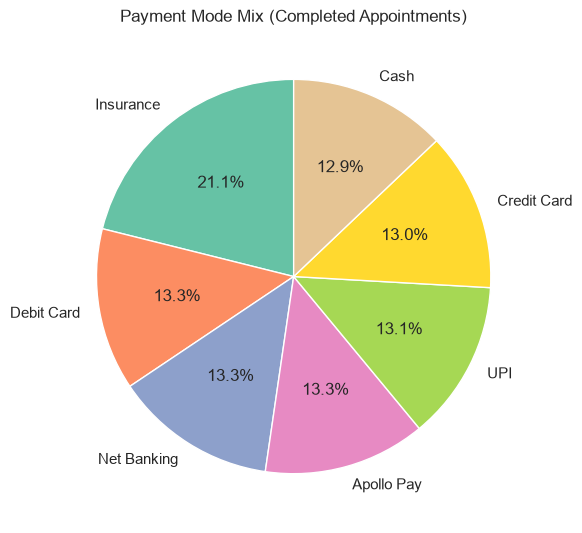

In [129]:
plt.figure(figsize=(6, 6))
plt.pie(payment_mix, labels=payment_mix.index, autopct="%1.1f%%", startangle=90,
        colors=sns.color_palette("Set2", len(payment_mix)))
plt.title("Payment Mode Mix (Completed Appointments)")
plt.tight_layout()
plt.show()

In [130]:
#Insurance vs out of pocket

In [131]:
completed["oop_share_pct"] = (completed["patient_out_of_pocket"] / completed["actual_fee_charged"] * 100).round(1)

insurance_oop = completed.groupby("insurance_coverage").agg(
    avg_out_of_pocket=("patient_out_of_pocket", "mean"),
    avg_oop_share_pct=("oop_share_pct", "mean"),
    appointments=("patient_out_of_pocket", "size")
).round(1)
insurance_oop

,avg_out_of_pocket,avg_oop_share_pct,appointments
insurance_coverage,,,
No,1562.8,100.0,37523
Yes,859.2,55.1,17752


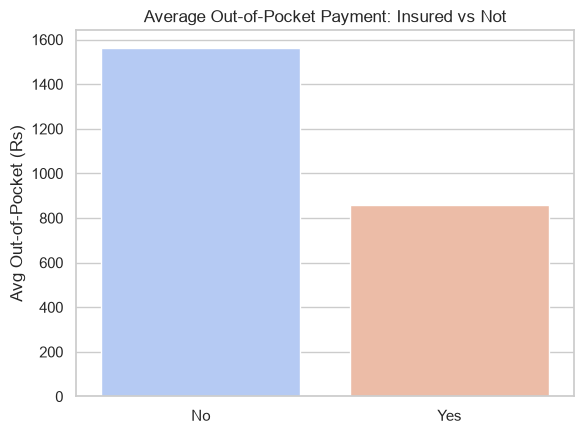

In [132]:
plt.figure(figsize=(6, 4.5))
sns.barplot(x=insurance_oop.index, y="avg_out_of_pocket", data=insurance_oop,
            hue=insurance_oop.index, palette="coolwarm", legend=False)
plt.title("Average Out-of-Pocket Payment: Insured vs Not")
plt.xlabel(""); plt.ylabel("Avg Out-of-Pocket (Rs)")
plt.tight_layout()
plt.show()

In [133]:
insured_completed = completed[completed["insurance_coverage"] == "Yes"]
zero_covered = (insured_completed["insurance_covered_amount"] == 0).sum()
print(f"Insured Completed appointments where insurer paid Rs 0: {zero_covered} of {len(insured_completed)}"
      f" ({zero_covered/len(insured_completed)*100:.1f}%)")

Insured Completed appointments where insurer paid Rs 0: 7091 of 17752 (39.9%)


In [134]:
#Doctor Utilisation & Service Quality 

In [135]:
#Utilisation by speciality

In [136]:
utilisation_by_specialty = completed.groupby("specialty")["doctor_utilization_pct"].mean().sort_values(ascending=False).round(1)
utilisation_by_specialty

specialty
Gastroenterology     77.3
Endocrinology        77.1
Cardiology           76.8
Gynaecology          76.8
Paediatrics          76.7
Neurology            76.6
General Physician    76.6
Urology              76.4
Orthopaedics         76.4
Dermatology          76.4
Pulmonology          76.4
ENT                  76.3
Ophthalmology        76.2
Psychiatry           76.2
Name: doctor_utilization_pct, dtype: float64

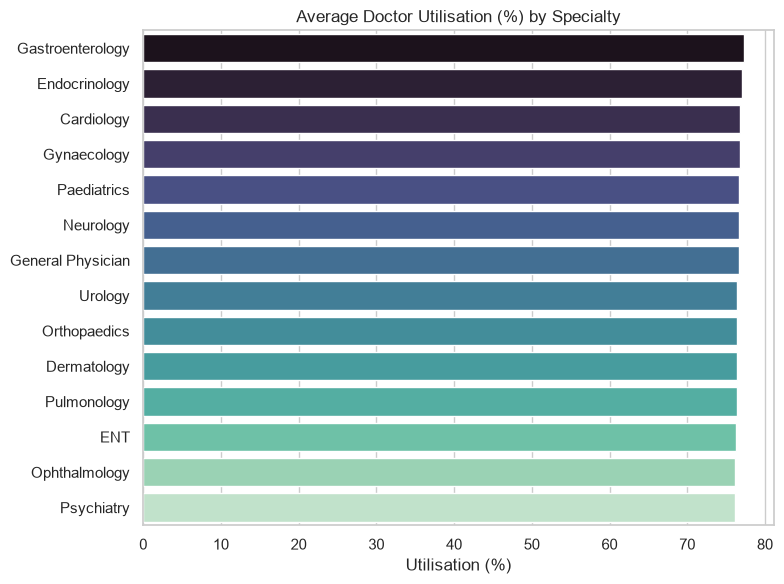

In [137]:
plt.figure(figsize=(8, 6))
sns.barplot(x=utilisation_by_specialty.values, y=utilisation_by_specialty.index,
            hue=utilisation_by_specialty.index, palette="mako", legend=False)
plt.title("Average Doctor Utilisation (%) by Specialty")
plt.xlabel("Utilisation (%)"); plt.ylabel("")
plt.tight_layout()
plt.show()

In [138]:
#Wait time

In [139]:
wait_by_specialty = completed.groupby("specialty")["wait_time_minutes"].agg(["mean", "median"]).round(1).sort_values("mean", ascending=False)
wait_by_specialty

,mean,median
specialty,,
Ophthalmology,12.0,8.0
Urology,11.9,8.0
Dermatology,11.8,8.0
Orthopaedics,11.7,8.0
Neurology,11.6,8.0
Cardiology,11.6,8.0
Gynaecology,11.6,8.0
Endocrinology,11.5,8.0
General Physician,11.5,8.0


In [140]:
wait_by_time = completed.groupby("time_of_day")["wait_time_minutes"].agg(["mean", "median"]).round(1)
wait_by_time

,mean,median
time_of_day,,
Afternoon,11.6,8.0
Evening,11.6,8.0
Morning,11.5,8.0


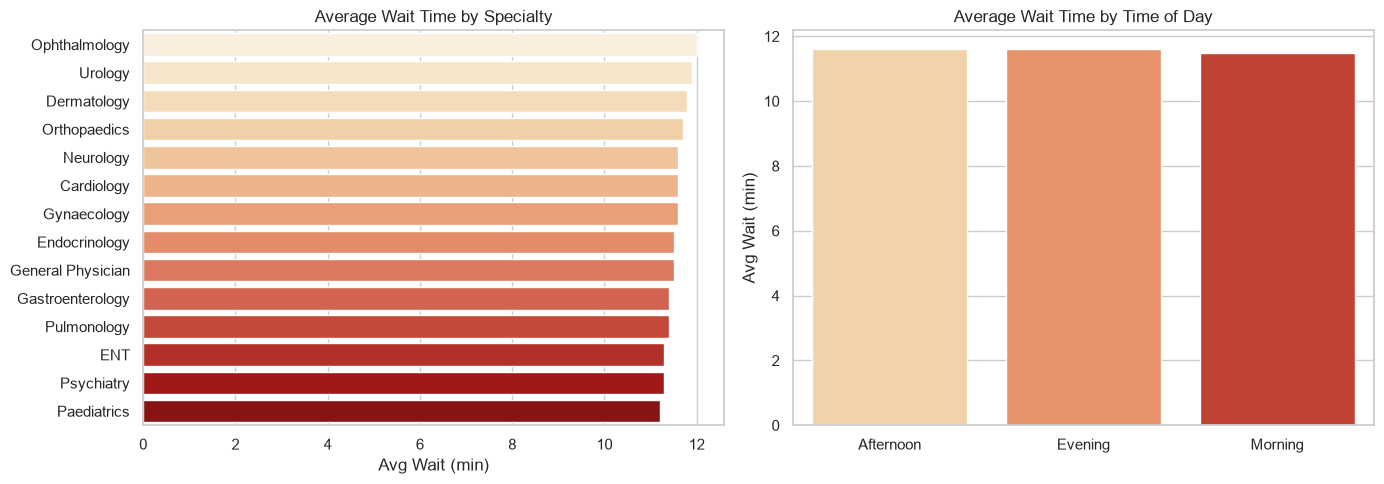

In [141]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=wait_by_specialty["mean"].values, y=wait_by_specialty.index,
            hue=wait_by_specialty.index, palette="OrRd", legend=False, ax=axes[0])
axes[0].set_title("Average Wait Time by Specialty")
axes[0].set_xlabel("Avg Wait (min)"); axes[0].set_ylabel("")

sns.barplot(x=wait_by_time.index, y=wait_by_time["mean"].values,
            hue=wait_by_time.index, palette="OrRd", legend=False, ax=axes[1])
axes[1].set_title("Average Wait Time by Time of Day")
axes[1].set_xlabel(""); axes[1].set_ylabel("Avg Wait (min)")

plt.tight_layout()
plt.show()

In [142]:
#duration vs satisfaction

In [143]:
corr, p_value = stats.pearsonr(completed["consultation_duration_min"], completed["patient_satisfaction_score"])
print(f"Correlation (duration vs satisfaction): r = {corr:.3f}, p-value = {p_value:.4f}")

Correlation (duration vs satisfaction): r = -0.004, p-value = 0.4099


In [144]:
duration_order = ["≤10 min", "11-20 min", "21-30 min", "31+ min"]
satisfaction_by_duration = completed.groupby("duration_band", observed=True)["patient_satisfaction_score"].mean().reindex(duration_order).round(2)
satisfaction_by_duration

duration_band
≤10 min      4.07
11-20 min    4.07
21-30 min    4.07
31+ min      4.07
Name: patient_satisfaction_score, dtype: float64

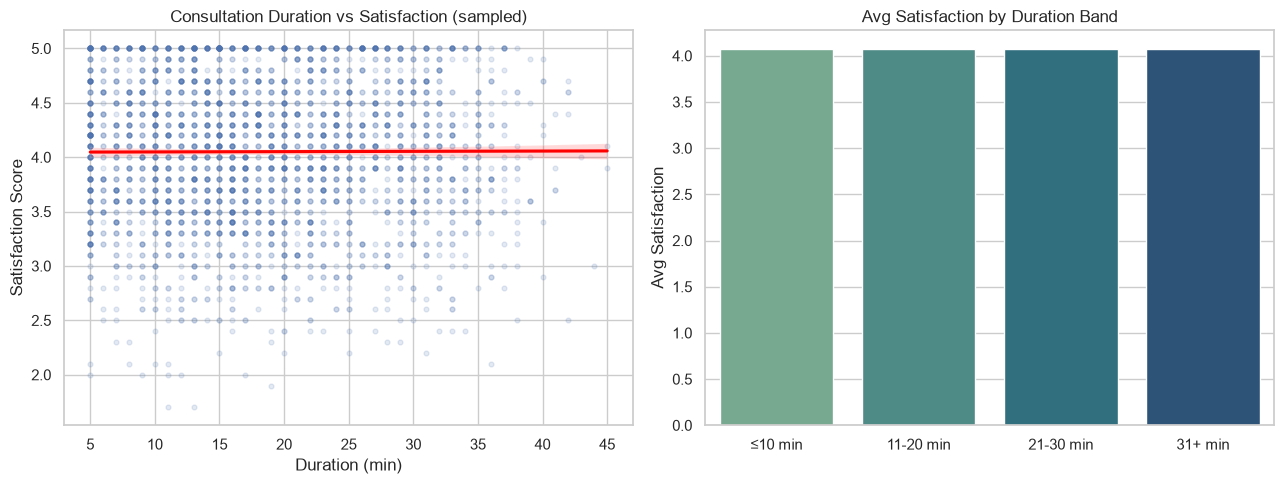

In [145]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sample = completed.sample(min(3000, len(completed)), random_state=42)
sns.regplot(x="consultation_duration_min", y="patient_satisfaction_score", data=sample,
            scatter_kws={"alpha": 0.15, "s": 12}, line_kws={"color": "red"}, ax=axes[0])
axes[0].set_title("Consultation Duration vs Satisfaction (sampled)")
axes[0].set_xlabel("Duration (min)"); axes[0].set_ylabel("Satisfaction Score")

sns.barplot(x=satisfaction_by_duration.index, y=satisfaction_by_duration.values,
            hue=satisfaction_by_duration.index, palette="crest", legend=False, ax=axes[1])
axes[1].set_title("Avg Satisfaction by Duration Band")
axes[1].set_xlabel(""); axes[1].set_ylabel("Avg Satisfaction")

plt.tight_layout()
plt.show()

In [146]:
#Experience vs fee

In [147]:
corr_fee, p_value_fee = stats.pearsonr(doctors["experience_years"], doctors["consultation_fee"])
print(f"Correlation (experience vs standard fee): r = {corr_fee:.3f}, p-value = {p_value_fee:.4f}")

Correlation (experience vs standard fee): r = 0.278, p-value = 0.0000


In [148]:
exp_bins   = [0, 5, 10, 20, 40]
exp_labels = ["2-5 yrs", "6-10 yrs", "11-20 yrs", "21+ yrs"]
doctors["experience_band"] = pd.cut(doctors["experience_years"], bins=exp_bins, labels=exp_labels)

fee_by_experience = doctors.groupby("experience_band", observed=True)["consultation_fee"].mean().round(0)
fee_by_experience

experience_band
2-5 yrs      1320.0
6-10 yrs     1445.0
11-20 yrs    1524.0
21+ yrs      1850.0
Name: consultation_fee, dtype: float64

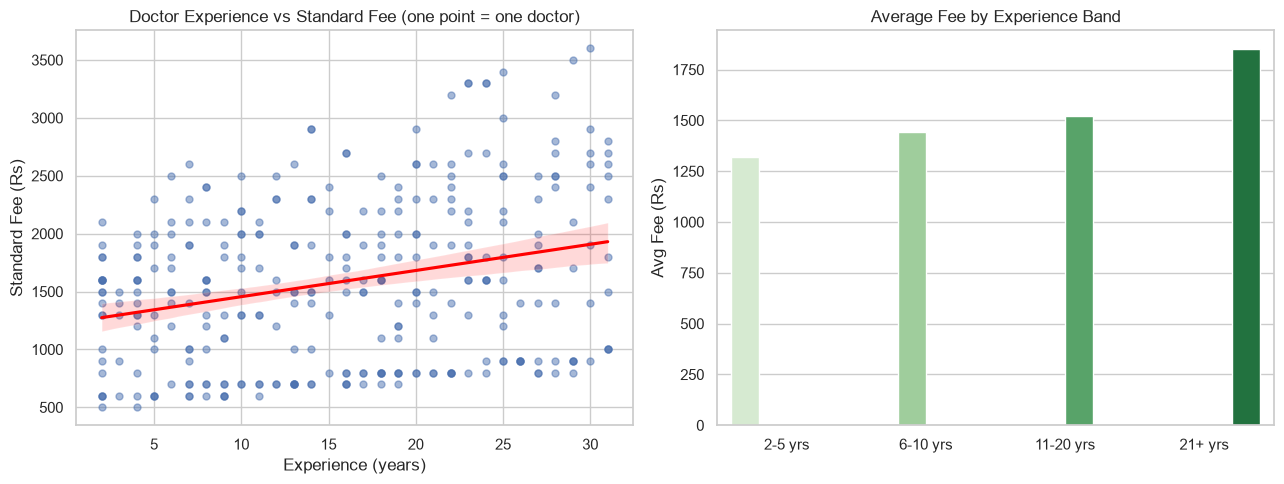

In [149]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.regplot(x="experience_years", y="consultation_fee", data=doctors,
            scatter_kws={"alpha": 0.5, "s": 25}, line_kws={"color": "red"}, ax=axes[0])
axes[0].set_title("Doctor Experience vs Standard Fee (one point = one doctor)")
axes[0].set_xlabel("Experience (years)"); axes[0].set_ylabel("Standard Fee (Rs)")

sns.barplot(x=fee_by_experience.index, y=fee_by_experience.values,
            hue=fee_by_experience.index, palette="Greens", legend=False, ax=axes[1])
axes[1].set_title("Average Fee by Experience Band")
axes[1].set_xlabel(""); axes[1].set_ylabel("Avg Fee (Rs)")

plt.tight_layout()
plt.show()